# Titanic Dataset: Outlier Detection & Treatment 
Topics:
1. Outlier Detection using the IQR Method
2. Outlier Detection using the Z-Score Method
3. Outlier Treatment using the Capping (Winsorization) Method



## Setup

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

%matplotlib inline
sns.set_style("whitegrid")
pd.set_option("display.max_columns", None)

# Option 1: Load from seaborn's built-in dataset


In [3]:
df=sns.load_dataset('titanic')

In [4]:
df.shape

(891, 15)

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 15 columns):
 #   Column       Non-Null Count  Dtype   
---  ------       --------------  -----   
 0   survived     891 non-null    int64   
 1   pclass       891 non-null    int64   
 2   sex          891 non-null    object  
 3   age          714 non-null    float64 
 4   sibsp        891 non-null    int64   
 5   parch        891 non-null    int64   
 6   fare         891 non-null    float64 
 7   embarked     889 non-null    object  
 8   class        891 non-null    category
 9   who          891 non-null    object  
 10  adult_male   891 non-null    bool    
 11  deck         203 non-null    category
 12  embark_town  889 non-null    object  
 13  alive        891 non-null    object  
 14  alone        891 non-null    bool    
dtypes: bool(2), category(2), float64(2), int64(4), object(5)
memory usage: 80.7+ KB


In [6]:
df.describe()

,survived,pclass,age,sibsp,parch,fare
count,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000
mean,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208
std,0.486592,0.836071,14.526497,1.102743,0.806057,49.693429
min,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,0.000000,2.000000,20.125000,0.000000,0.000000,7.910400
50%,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000
max,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


<Axes: xlabel='fare'>

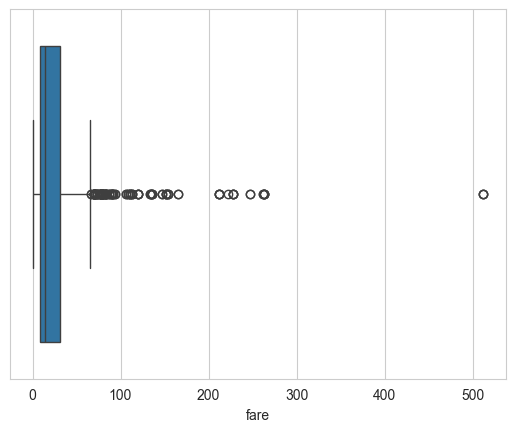

In [7]:
sns.boxplot(x=df['fare'])

## Q21. IQR-Based Outlier Detection on Fare
Using the IQR method, calculate the lower and upper bounds for `Fare`. How many passengers fall outside these bounds, and what percentage of the dataset do they represent?


In [8]:
df['fare']

0       7.2500
1      71.2833
2       7.9250
3      53.1000
4       8.0500
        ...   
886    13.0000
887    30.0000
888    23.4500
889    30.0000
890     7.7500
Name: fare, Length: 891, dtype: float64

In [9]:

# Calculate Q1, Q3 and IQR
# Calculate Lower Bound and Upper Bound
# Q1=np.percentile(df['fare'],25)
# Q3=np.percentile(df['fare'],75)

Q1=df['fare'].quantile(0.25)
Q3=df['fare'].quantile(0.75)

IQR=Q3-Q1

upper_bound=Q3+1.5*IQR
lower_bound=Q1-1.5*IQR

fare_outliers=df[(df['fare'] < lower_bound) | (df['fare'] > upper_bound)]


print(f"Q1: {Q1:.2f}, Q3: {Q3:.2f}, IQR: {IQR:.2f}")
print(f"Lower bound: {lower_bound:.2f}, Upper bound: {upper_bound:.2f}")
print(f"Number of Fare outliers: {len(fare_outliers)}")
print(f"Percentage of dataset: {len(fare_outliers) / len(df) * 100:.2f}%")


Q1: 7.91, Q3: 31.00, IQR: 23.09
Lower bound: -26.72, Upper bound: 65.63
Number of Fare outliers: 116
Percentage of dataset: 13.02%


## Q22. IQR-Based Outlier Detection on Age
Repeat the IQR-based outlier detection for `Age`. Are there fewer or more outliers compared to `Fare`? What does this tell you about the relative "spread" of the two features?


In [17]:
# Delete recods where Age is Missing.
age=df['age'].dropna()

# Calculate Q1, Q3 and IQR
Q1_age=age.quantile(0.25)
Q3_age=age.quantile(0.75)

IQR_age=Q3_age-Q1_age
# Calculate Lower Bound and Upper Bound
lower_bound_age=Q1_age-(1.5*IQR_age)
upper_bound_age=Q3_age+(1.5*IQR_age)


age_outliers=df[(df['age'].notna()) &
    ((df['age']<lower_bound_age) | (df['age']>upper_bound_age))]







print(f"Q1: {Q1_age:.2f}, Q3: {Q3_age:.2f}, IQR: {IQR_age:.2f}")
print(f"Lower bound: {lower_bound_age:.2f}, Upper bound: {upper_bound_age:.2f}")
print(f"Number of Age outliers: {len(age_outliers)}")
print(f"Percentage of non-missing Age values: {len(age_outliers) / len(age) * 100:.2f}%")

print(f"\nComparison -> Fare outliers: {len(fare_outliers)} ({len(fare_outliers)/len(df)*100:.2f}%) "
      f"vs Age outliers: {len(age_outliers)} ({len(age_outliers)/len(age)*100:.2f}%)")




Q1: 20.12, Q3: 38.00, IQR: 17.88
Lower bound: -6.69, Upper bound: 64.81
Number of Age outliers: 11
Percentage of non-missing Age values: 1.54%

Comparison -> Fare outliers: 116 (13.02%) vs Age outliers: 11 (1.54%)


## Q23. Z-Score-Based Outlier Detection on Fare
Calculate the Z-score for every value in the `Fare` column. Using a threshold of |Z| > 3, how many outliers does the Z-score method flag?


In [11]:
from scipy import stats
from scipy.stats import zscore
# Calculate Mean and Standard Deviation of Fare
mean_fare=df['fare'].mean()
std_fare=df['fare'].std()



# Calulate Z-Score
z_score=(df['fare']-mean_fare)/std_fare

# z_score=zscore(fare) can also be used

# FInd Outliers based on Z-Score (|Z| > 3)

z_outliers=df[abs(z_score)>3]

print(f"Mean Fare: {mean_fare:.2f}, Std Fare: {std_fare:.2f}")
print(f"Number of Z-score outliers (|Z| > 3): {len(z_outliers)}")


Mean Fare: 32.20, Std Fare: 49.69
Number of Z-score outliers (|Z| > 3): 20


## Q24. Comparing IQR vs Z-Score Outliers on Fare
Compare the outliers flagged by the IQR method (Q21) and the Z-score method (Q23) for `Fare`. Do both methods agree on the same records? Where do they differ, and why might that happen given Fare's distribution?


In [16]:
iqr_outlier_idx = set(fare_outliers.index)
z_outlier_idx = set(z_outliers.index)

both = iqr_outlier_idx & z_outlier_idx
only_iqr = iqr_outlier_idx - z_outlier_idx
only_z = z_outlier_idx - iqr_outlier_idx

print(f"Flagged by BOTH methods: {len(both)}")
print(f"Flagged ONLY by IQR: {len(only_iqr)}")
print(f"Flagged ONLY by Z-score: {len(only_z)}")


Flagged by BOTH methods: 20
Flagged ONLY by IQR: 96
Flagged ONLY by Z-score: 0


## Q25. Choosing the Right Method: Normality Check
The Z-score method assumes the data is approximately normally distributed. Plot the distribution of `Fare` and `Age` and discuss which feature is a better candidate for Z-score-based outlier detection versus IQR-based detection.


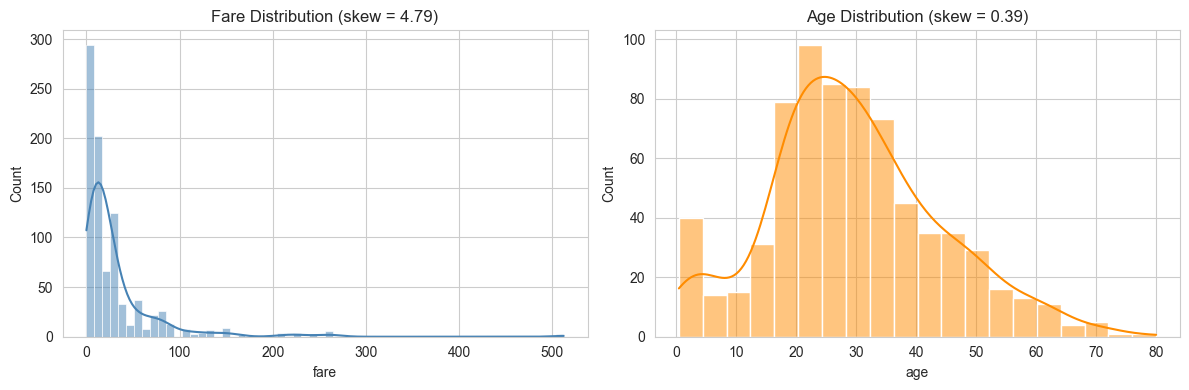

Fare skewness: 4.79
Age skewness: 0.39


In [13]:
# 1. Plot histograms (with KDE) for 'fare' and 'age' side by side
# 2. Optionally compute skewness for both: df['fare'].skew(), df['age'].skew()
# 3. Visually/numerically assess how close each is to a normal distribution

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Fare distribution
sns.histplot(df['fare'], kde=True, ax=axes[0], color='steelblue')
axes[0].set_title(f"Fare Distribution (skew = {df['fare'].skew():.2f})")

# Age distribution
sns.histplot(df['age'].dropna(), kde=True, ax=axes[1], color='darkorange')
axes[1].set_title(f"Age Distribution (skew = {df['age'].skew():.2f})")

plt.tight_layout()
plt.show()

print(f"Fare skewness: {df['fare'].skew():.2f}")
print(f"Age skewness: {df['age'].skew():.2f}")


---
# Section 6: Outlier Treatment (Capping Method)


## Q26. IQR-Based Capping (Winsorization) on Fare
Using the IQR bounds calculated in Q21, apply capping (winsorization) to the `Fare` column — replace values below the lower bound with the lower bound, and values above the upper bound with the upper bound. Compare the mean, median, and standard deviation of `Fare` before and after capping.


In [23]:
# Create a copy of Dataframe to cap the outliers in 'fare' column
df_capped=df.copy();



# Cap the outliers in the 'fare' column
df_capped['fare']=np.where(df_capped['fare']>upper_bound,upper_bound,
                           np.where(df_capped['fare']<lower_bound,lower_bound,df_capped['fare']))



#Check the statistics before and after capping
print("Before capping:")
print(f"  Mean: {df['fare'].mean():.2f}, Median: {df['fare'].median():.2f}, Std: {df['fare'].std():.2f}")

print("After capping:")
print(f"  Mean: {df_capped['fare'].mean():.2f}, Median: {df_capped['fare'].median():.2f}, Std: {df_capped['fare'].std():.2f}")


Before capping:
  Mean: 32.20, Median: 14.45, Std: 49.69
After capping:
  Mean: 24.05, Median: 14.45, Std: 20.48


## Q27. Visualizing the Effect of Capping
Plot boxplots of `Fare` before and after capping, side by side. How does the visual spread of the data change, and are there still any points shown as outliers?


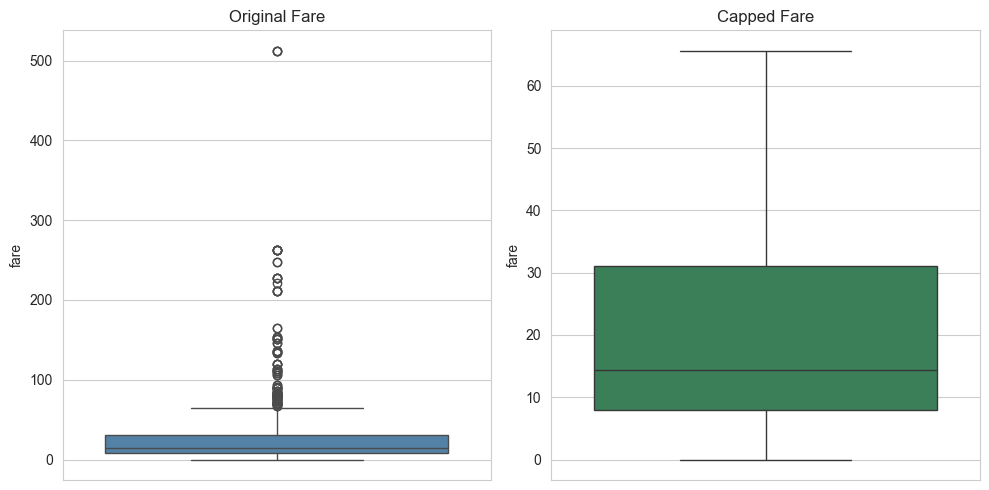

In [24]:
fig, axes = plt.subplots(1, 2, figsize=(10, 5))

# Boxplot of original 'fare'
sns.boxplot(y=df['fare'], ax=axes[0], color='steelblue')
axes[0].set_title("Original Fare")

# Boxplot of capped 'fare' (df_capped)
sns.boxplot(y=df_capped['fare'], ax=axes[1], color='seagreen')
axes[1].set_title("Capped Fare")

plt.tight_layout()
plt.show()


## Q28. Percentile-Based Capping
Apply percentile-based capping to `Fare` — cap all values below the 1st percentile and above the 99th percentile. How do the resulting bounds differ from the 1.5×IQR bounds used in Q26?


In [29]:
# Cap the outliers in the 'fare' column using 1st and 99th percentiles
p01 = df['fare'].quantile(0.01)
p99 = df['fare'].quantile(0.99)

df_pct_capped = df.copy()
df_pct_capped['fare'] = np.where(df_pct_capped['fare'] > p99, p99,
                          np.where(df_pct_capped['fare'] < p01, p01, df_pct_capped['fare']))

print(f"1st percentile: {p01:.2f}, 99th percentile: {p99:.2f}")
print(f"IQR bounds (Q21/Q26): lower={lower_bound:.2f}, upper={upper_bound:.2f}")


1st percentile: 0.00, 99th percentile: 249.01
IQR bounds (Q21/Q26): lower=-26.72, upper=65.63


## Q29. Z-Score-Based Capping on Age
Apply Z-score-based capping to `Age` — cap any value with |Z| > 3 to the corresponding boundary value (mean ± 3×std). Compare the number of values affected by this method versus the IQR capping approach.


In [ ]:
For 

For z_score our lower bound and upper bounds are -
lower_z_bound=mean-3*std
upper_z_buond=mean+3*std

In [28]:
age_clean = df['age'].dropna()
# Calulate Mean and Standard Deviation of Age
mean_age=age_clean.mean()
std_age=age_clean.std()
# Calculate Lower and Upper Z bounds for Age
lower_z_bound=mean_age-(3*std_age)
upper_z_bound=mean_age+(3*std_age)

#Apply Capping
df_age_capped = df.copy()
df_age_capped['age'] = np.where(df_age_capped['age'] > upper_z_bound, upper_z_bound,
                        np.where(df_age_capped['age'] < lower_z_bound, lower_z_bound, df_age_capped['age']))

n_changed = ((age_clean > upper_z_bound) | (age_clean < lower_z_bound)).sum()

print(f"Mean Age: {mean_age:.2f}, Std Age: {std_age:.2f}")
print(f"Lower Z bound: {lower_z_bound:.2f}, Upper Z bound: {upper_z_bound:.2f}")
print(f"Number of Age values capped (Z-score method): {n_changed}")
print(f"Number of Age outliers from IQR method (Q22): {len(age_outliers)}")


Mean Age: 29.70, Std Age: 14.53
Lower Z bound: -13.88, Upper Z bound: 73.28
Number of Age values capped (Z-score method): 2
Number of Age outliers from IQR method (Q22): 11


## Q30. Capping vs Removal — Discussion
Capping changes the underlying distribution of a feature rather than removing data points. Discuss: in what situations would you prefer capping over removing outliers entirely, and what risk does capping introduce if applied carelessly to a legitimately skewed feature like `Fare`?
